# Bonus – Chemostat with mixed-growth-associated product formation

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# Parameters (from problem statement)
mu_m  = 0.7    # h-1   maximum specific growth rate
Ks    = 0.020  # g/L   half-saturation constant (given as 20 mg/L)
Yxs   = 0.5    # g cell / g substrate  (Yxs_max from problem)
alpha = 0.1    # growth-associated product coefficient
beta  = 0.02   # h-1   non-growth-associated product coefficient
S0    = 1.0    # g/L   feed substrate concentration
X0    = 0.0    # g/L   feed cell concentration

## Model

The specific growth rate follows standard Monod kinetics:
$$\mu = \frac{\mu_m S}{K_s + S}$$

The product formation rate is mixed-growth-associated (Luedeking-Piret):
$$r_p = \alpha \mu + \beta$$

At steady state in a chemostat ($D = \mu$), the substrate balance gives:
$$S = \frac{D K_s}{\mu_m - D}$$

From the cell and product mass balances:
$$X = Y_{x/s}(S_0 - S) \qquad P = \left(\alpha + \frac{\beta}{D}\right) X$$

Washout occurs when $D = \mu(S_0)$, i.e. when the reactor cannot sustain cells at the given feed concentration.

In [9]:
def mu(S):
    return mu_m * S / (Ks + S)

def steady_state(D):
    """Steady-state (S, X, P) for a given D. Returns NaN if washout."""
    if D >= mu_m:
        return np.nan, np.nan, np.nan
    S = D * Ks / (mu_m - D)
    if S <= 0 or S >= S0:
        return np.nan, np.nan, np.nan
    X = Yxs * (S0 - S)
    P = (alpha + beta / D) * X
    return S, X, P

D_washout = mu(S0)
print(f"Washout dilution rate  D_washout = mu(S0) = {D_washout:.4f} h-1")
print(f"(Washout occurs when S_ss = S0, i.e. X -> 0)")

# Scan D from near 0 to just below washout
D_upper = D_washout * 0.9999
D_range = np.linspace(1e-4, D_upper, 10000)
out   = np.array([steady_state(D) for D in D_range])
S_arr = out[:, 0]
X_arr = out[:, 1]
P_arr = out[:, 2]
Pi_P  = D_range * P_arr
Pi_X  = D_range * X_arr

valid  = ~np.isnan(Pi_P)
D_v    = D_range[valid]
Pi_P_v = Pi_P[valid]
Pi_X_v = Pi_X[valid]
S_v    = S_arr[valid]
X_v    = X_arr[valid]
P_v    = P_arr[valid]

Washout dilution rate  D_washout = mu(S0) = 0.6863 h-1
(Washout occurs when S_ss = S0, i.e. X -> 0)


## a) Optimal dilution rate for product productivity $\Pi_P = D \cdot P$

In [10]:
def neg_Pi_P(D):
    S, X, P = steady_state(D)
    return 0.0 if np.isnan(P) else -D * P

res_P  = minimize_scalar(neg_Pi_P, bounds=(1e-4, D_upper), method='bounded')
D_optP = res_P.x
Sp, Xp, Pp = steady_state(D_optP)

print(f"Optimal D  = {D_optP:.4f} h-1")
print(f"S_ss       = {Sp*1000:.2f} mg/L")
print(f"X_ss       = {Xp:.4f} g/L")
print(f"P_ss       = {Pp:.4f} g/L")
print(f"Pi_P (max) = {D_optP * Pp:.5f} g/(L.h)")

Optimal D  = 0.5889 h-1
S_ss       = 105.96 mg/L
X_ss       = 0.4470 g/L
P_ss       = 0.0599 g/L
Pi_P (max) = 0.03526 g/(L.h)


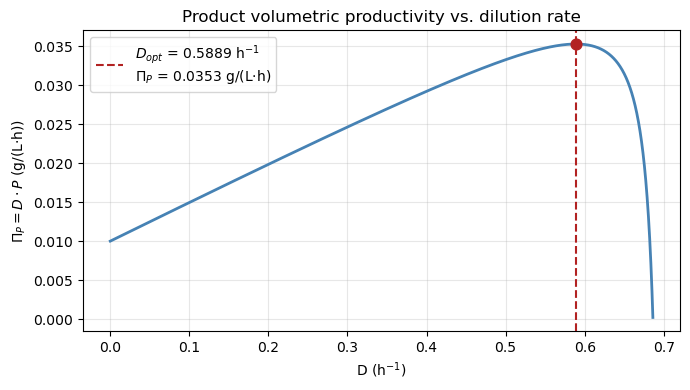

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(D_v, Pi_P_v, color='steelblue', lw=2)
ax.axvline(D_optP, color='firebrick', ls='--', lw=1.5,
           label=f'$D_{{opt}}$ = {D_optP:.4f} h$^{{-1}}$\n$\\Pi_P$ = {D_optP*Pp:.4f} g/(L·h)')
ax.scatter([D_optP], [D_optP * Pp], color='firebrick', zorder=5, s=60)
ax.set_xlabel('D (h$^{-1}$)')
ax.set_ylabel('$\\Pi_P = D \\cdot P$ (g/(L·h))')
ax.set_title('Product volumetric productivity vs. dilution rate')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bonus_a_product_productivity.png', dpi=150)
plt.show()

**Interpretation:** At low $D$, the non-growth-associated term $\beta$ leads to high $P$ concentration, but the low throughput limits $\Pi_P$. Near washout, $X$ and therefore $P$ drop sharply. The maximum of $\Pi_P$ represents the best trade-off between these two effects. Since $\Pi_P = (\alpha D + \beta) \cdot X$, the non-growth term $\beta$ shifts the optimum to a lower $D$ compared to $\Pi_X$.

## b) Optimal dilution rate for biomass productivity $\Pi_X = D \cdot X$

In [12]:
def neg_Pi_X(D):
    S, X, P = steady_state(D)
    return 0.0 if np.isnan(X) else -D * X

res_X  = minimize_scalar(neg_Pi_X, bounds=(1e-4, D_upper), method='bounded')
D_optX = res_X.x
Sx, Xx, Px = steady_state(D_optX)

# Analytical formula: D_opt = mu_m * (1 - sqrt(Ks / (Ks + S0)))
D_optX_analytical = mu_m * (1 - np.sqrt(Ks / (Ks + S0)))

print(f"Optimal D  = {D_optX:.4f} h-1")
print(f"  (analytical: mu_m*(1 - sqrt(Ks/(Ks+S0))) = {D_optX_analytical:.4f} h-1)")
print(f"S_ss       = {Sx*1000:.2f} mg/L")
print(f"X_ss       = {Xx:.4f} g/L")
print(f"Pi_X (max) = {D_optX * Xx:.5f} g/(L.h)")

Optimal D  = 0.6020 h-1
  (analytical: mu_m*(1 - sqrt(Ks/(Ks+S0))) = 0.6020 h-1)
S_ss       = 122.83 mg/L
X_ss       = 0.4386 g/L
Pi_X (max) = 0.26402 g/(L.h)


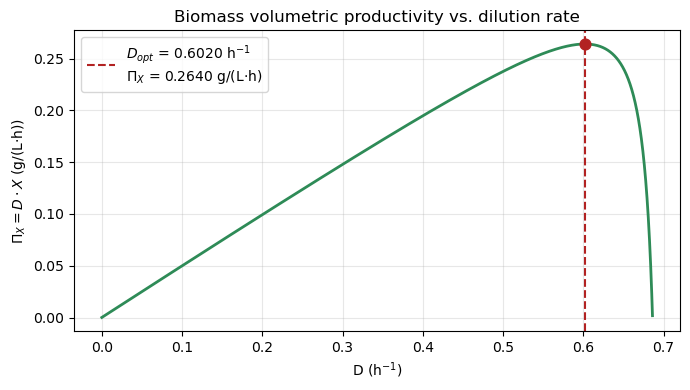

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(D_v, Pi_X_v, color='seagreen', lw=2)
ax.axvline(D_optX, color='firebrick', ls='--', lw=1.5,
           label=f'$D_{{opt}}$ = {D_optX:.4f} h$^{{-1}}$\n$\\Pi_X$ = {D_optX*Xx:.4f} g/(L·h)')
ax.scatter([D_optX], [D_optX * Xx], color='firebrick', zorder=5, s=60)
ax.set_xlabel('D (h$^{-1}$)')
ax.set_ylabel('$\\Pi_X = D \\cdot X$ (g/(L·h))')
ax.set_title('Biomass volumetric productivity vs. dilution rate')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bonus_b_biomass_productivity.png', dpi=150)
plt.show()

**Interpretation:** $\Pi_X = D \cdot X$ shows a clear maximum before washout. Increasing $D$ raises throughput but also reduces residence time, so $X$ drops. The optimum balances these effects. The analytical optimum $D_{opt} = \mu_m\left(1 - \sqrt{\dfrac{K_s}{K_s + S_0}}\right)$ is the classical result for Monod kinetics. Since $K_s \ll S_0$, the optimum is close to (but below) $\mu_m$.